# ARAGO TECHNICAL ASSIGNMENT
### AI/ML ENGINEER: INFERENCE OPTIMIZATION

This report provides a detailed account of the tasks listed in Assignment Section 2.2, Task Requirements, of the assignment. Although the five questions are answered as five separate tasks in this notebook, they are closely related and build on one another logically. Given the length constraints, this notebook includes as much of the supporting argument as possible while answering each question with empirical data. A great deal of the detailed code, testing, and reasoning cannot be shown here in full; all of it is preserved in the five notebooks listed below.

 **1 model profile**: A theoretical roofline analysis of Llama 3.1 8B under the given conditions

**2 hardware profile**: Discusses in detail the hardware modeling process and the performance analysis, and most importantly, provides a complete codebase for performance analysis.

**3 Flash attention**: The design of flash attention, how to optimize the kernel, the choice of tiling settings, and the SRAM allocation strategy

**4 MLP**: GEMM algorithm design, focusing on the Q/K/V computation in attention and the parallel computation of the MLP

**5 performance parallelization**: Performance analysis using the performance model, together with a discussion of parallelization strategies

Throughout this project, the following criteria were consistently observed across all tasks.

1 **Prefill | Decode seperation for every section**

2 **Algorithm design is always tailored to the characteristics of the accelerator itself**

3 **Every analysis comprises two parts: an analytical performance analysis and a simulation with the actual performance model. neither can be omitted.**

Finally, the table of contents of this notebook is as follows: An introduction for the background + Task 1 -> Task 5 analysis

******************************************************************************************

# Introduction: Methodology

For this project, a performance model was built to simulate the behaviour of the entire hardware setting conveniently and accurately. The first step was to translate the hardware specifications given in the assignment into a pipeline diagram: begin by laying out the accelerator's components and the links between them, so that the byte movement and latency between them can be seen at a glance. The hardware in the diagram was then implemented as Python classes, with every operation exposed as an API, so that subsequent algorithm runs can simply call these APIs, which return runtime data such as execution time, latency, and utilization. With this model and its APIs in place, our pseudocode can call them directly to test the algorithms.

In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/
from helper import plot

## Hardware performance modeling


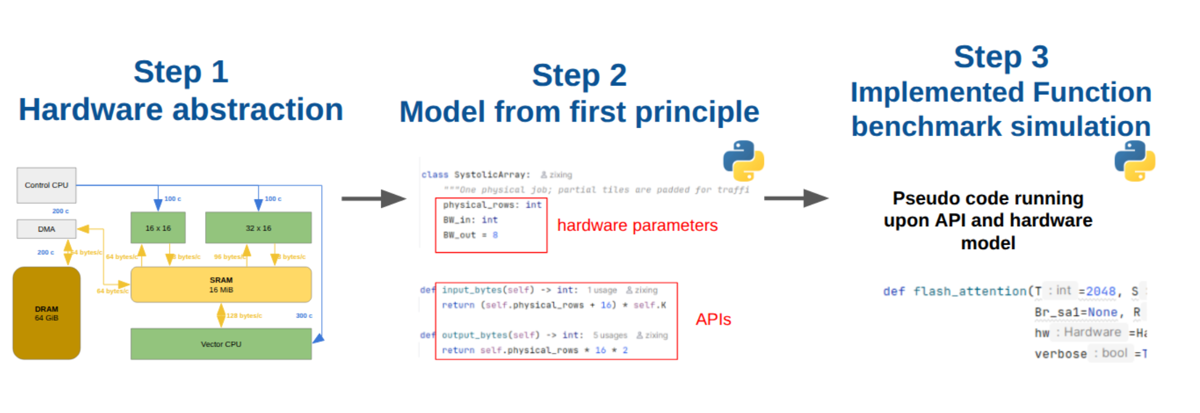

In [2]:
plot("img/workflow.png",1200)

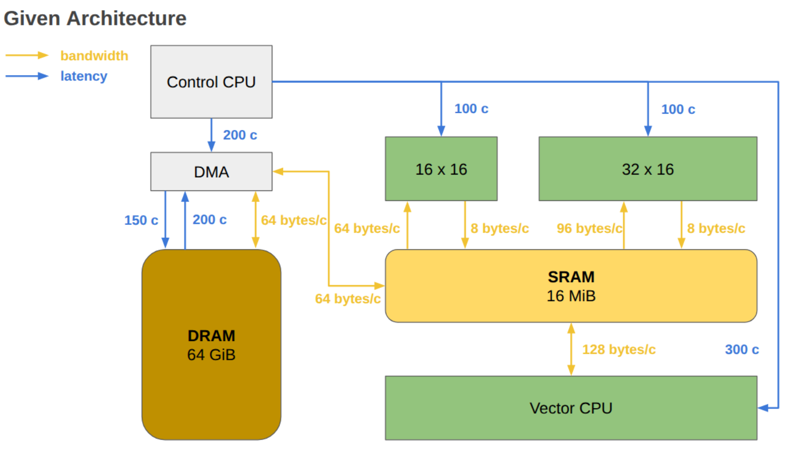

In [3]:
plot("img/architecture.png", 800)

### Bandwidth model (photonic chip) and MAC model (GPU)

We start with the two SA units. The SA is the primary compute unit for matrix operations, and in an LLM it handles essentially all the major GEMMs. Its efficiency depends on both its clock frequency and its design, so the performance analysis of the SA is split into two cases.

The first case is the bandwidth model, in which performance is determined by the bandwidth of the unit, a photonic chip, for example, can complete an entire GEMM operation in a single cycle. By contrast, a conventional GPU tensor core is designed to complete one multiply-accumulate per cycle, so throughput is governed by the reduction size (R in the assignment), with one R consumed per cycle. The performance model built on this assumption is called the MAC model.

### Theoretical benchmark: Roofline analysis

This roofline analysis measures the model's theoretical arithmetic intensity, which serves as the optimization target and benchmark for the work that follows.

Given the chip architecture and model hyperparameter, we plot the roofline:

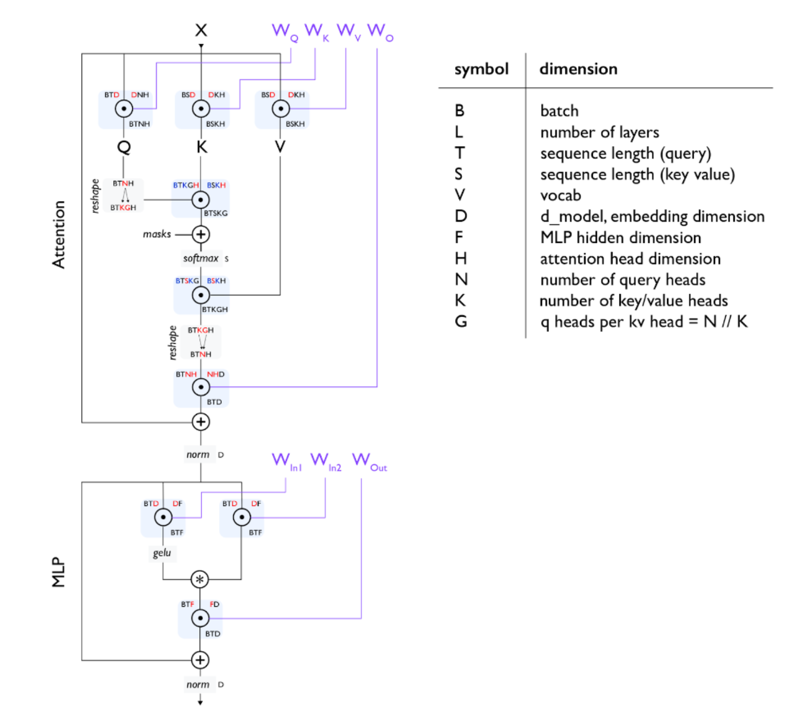

In [4]:
img = "img/LLM_tuning.png"
plot("img/LLM_tuning.png", 800)

B = 16 # Batch size
L = 32 # Layers
T = 2048 # Q length
S = 2048 # K length
D = 4096 # dimension
F = 14336 # FFN inter dim
N = 32 # Q head
K = 8 # KV head
H = 128 # d_head
G = int(N / K) # Q heads / KV head
d_kv = 1024 # d_kv


# Attention
Q_shape = B * T * K * G * H # 16 x 2048 x 8 x 4 x 128
K_shape = B * S * K * H # 16 x 2048 x 8 x 128
V_shape = B * S * K * H # 16 x 2048 x 8 x 128



chip ridge = 48.0


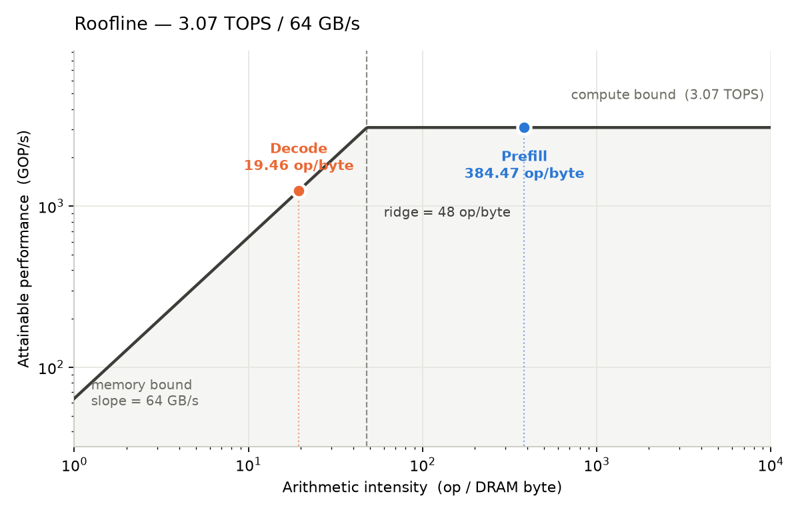

In [5]:
ridge_K_SA1 = 128
ridge_K_SA2 = 256
ops_SA1 = (2 * 16 * ridge_K_SA1 * 16) / 64
ops_SA2 = (2 * 32 * ridge_K_SA2 * 16) / 128
peak_ops = ops_SA1 + ops_SA2

peak_mem = 64 # DRAM -> SRAM

print(f"chip ridge = {peak_ops / peak_mem}")

plot(f"img/roofline.png", 800)

Summarizing the results above gives the theoretical FLOPs, bytes transferred, and arithmetic intensity for prefill and decode. The peak intensity of the SA on the two accelerators is taken as the ridge point. Prefill reaches 384 op/byte, making it clearly compute-bound, whereas decode has an intensity of 19.4 op/byte and is therefore memory-bound.

1. **Prefill Intensity: 384.47 FLOPs/byte:**

Total FLOPs: 493,127,714,471,936

Total bytes transferred: 1,282,601,910,272

2. **Decode Intensity: 19.46 FLOPs/byte**

Total FLOPs: 61,668,100,945,920

Total bytes transferred: 3,108,240,875,520

Total bits transferred: 24,865,927,004,160

# I. Task 1

_Provide a pseudocode implementation of an optimized flash-attention kernel for this architecture,
detailing the SRAM allocation strategy, the tiling strategy and the overall computation dataflow.
Keep in mind that this code, once implemented, would be executed on the control CPU._


### FA2 Prefill

First take sequential flash attention as the benchmark. This implementation follows Algorithm 1 of FlashAttention-2 directly: all QK and PV products run on the SA units, while the remaining non-GEMM operations run on the VCPU. The algorithm roughly divides the whole process into S = QK, U = PV, int16 → int8 conversion, and other non-GEMM operations.



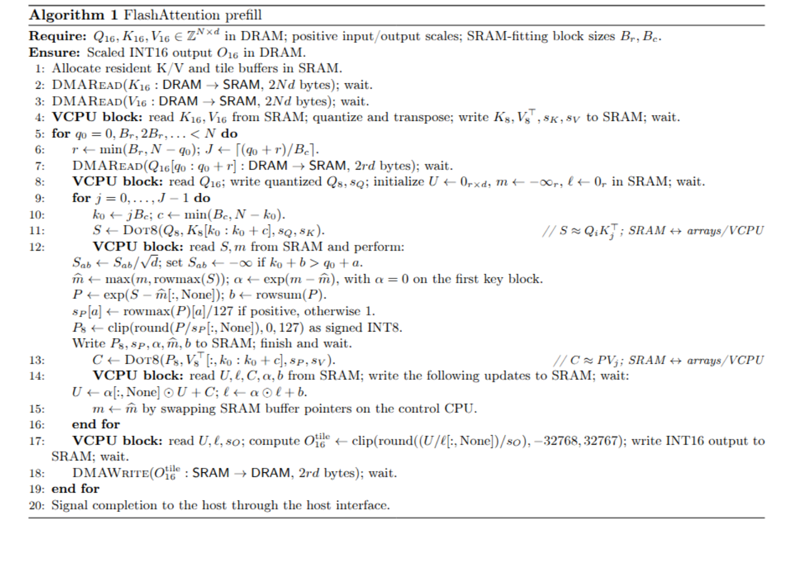

In [6]:
plot("img/fa2_prefill.png", 800)

### Schedule bubble

Looking at the Gantt plot, there are two kinds of scheduling bubbles. Those outlined in green: while the SA is busy the VCPU sits idle, and while the VCPU is busy the SA sits idle. Those outlined in red: scheduling blocks with no dependency between them could be computed in parallel instead of waiting on one another.

• green: the SA idles while the VCPU works, and vice versa

• red: independent tasks that wait on each other although they could overlap.

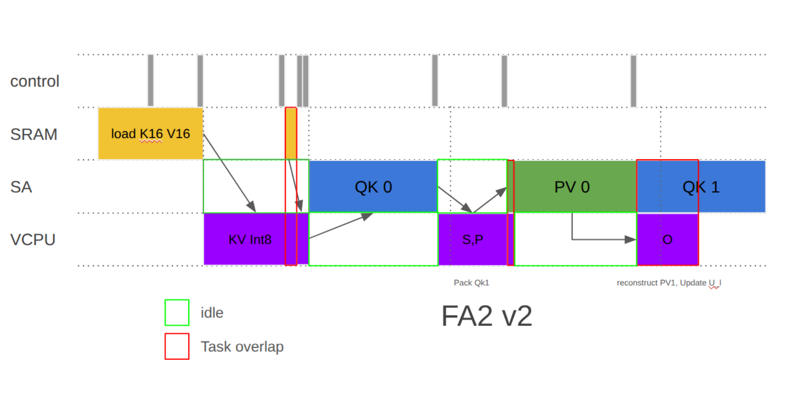

In [7]:
plot("img/schedule_bubble.png", 800)

In fact, the task dependencies in FA2 can be decomposed at a finer granularity to reduce both kinds of bubbles. The SA-VCPU idling in particular can be addressed by a more fine-grained online softmax.

In fact, as shown below, Qi, mi, li and Pi, whose dependencies are explicit. Reordering the tasks by dependency
lets the softmax of block p hide under the score GEMM of block p+1


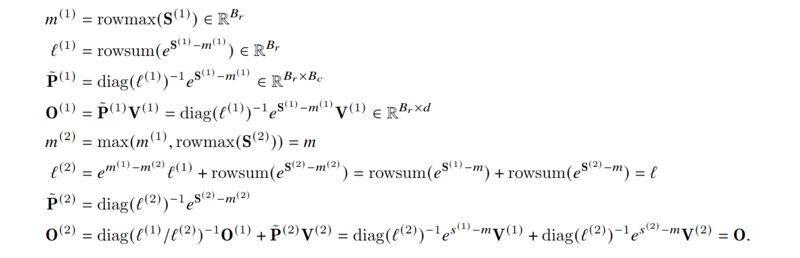

In [8]:
plot("img/online_softmax.png", 800)

After rebuild the dependency graph:

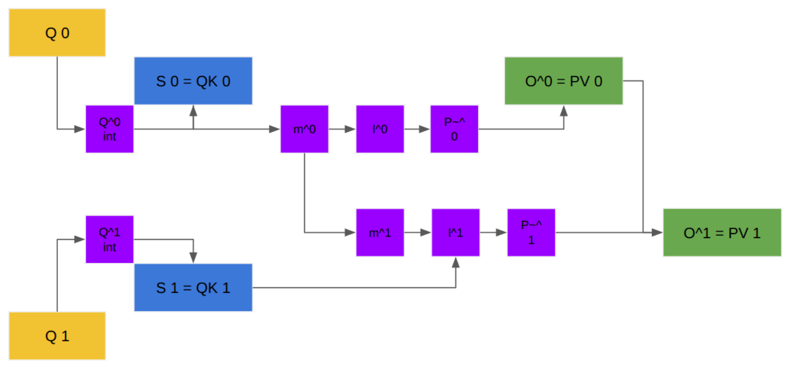

In [9]:
plot("img/schedule_dependency.png", 800)

Reordering these tasks according to their dependencies, we obtain:

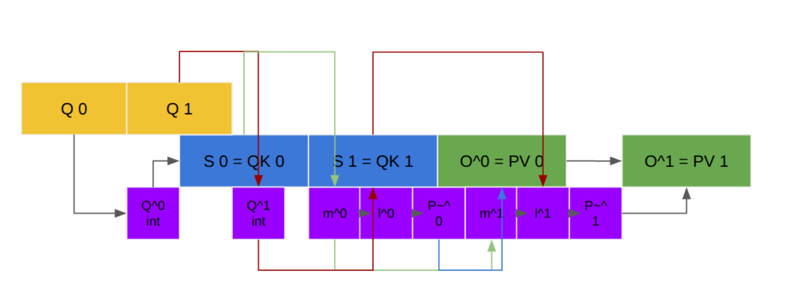

In [10]:
plot("img/schedule_pipeline.png", 800)

### FA for Decode

The FA algorithm during decode is almost identical to the one used during prefill. In decode, 4 Q share 1 KV. Every cached key is visible to the G query heads. The keys are the array rows, so both arrays share every GEMM. However, Q has a sequence length of only 1, so even after merging four Q's, the two SAs still cannot be fully saturated. The strategy is therefore:

Q: B × G × 1 × H = 16 x 4 x 1 x 128

K,V: B × 1 × S × H = 16 x 1 x 2048 x 128

$$S = QK^T -> S^T = K Q^T$$

The transported size: 4 x 128, 128 x 1024 (Bc) -> 1024 (Bc) x 128, 128 x 4

Below is a performance simulation of two strategy, we see by transpose Q K achieves a roughly 40% speedup

In [38]:
from fa import flash_attention, flash_decode

Bc = 1024
qk = flash_attention(T=G, S=S, H=H, G=1, Br=G, Bc=Bc, R=256, causal=False, verbose=False)
kq = flash_decode(S=S, H=H, G=G, Bc=Bc, R=256, verbose=False)
for name, job in (("S   = Q K^T", qk), ("S^T = K Q^T", kq)):
    print(f"Bc={Bc:4d}  {name}: {job['cycles']:6d} cycles, arrays {job['utilization']['SA1+SA2']:.0%}")

Bc=1024  S   = Q K^T:  75547 cycles, arrays 69%
Bc=1024  S^T = K Q^T:  35655 cycles, arrays 54%


### Tiling strategy

The work is tiled on four nested levels:
1. KV-head group. K16 and V16 (S × H) are loaded and quantized once, then reused by all
G=4 query heads.
2. Query tile × key block. Q is cut into tiles of **Br** rows and K, V into blocks of **Bc** keys. A
causal pair is visited only if j < i+Br.
3. GEMM orientation. Scores: S[m×c] = Q8[m×H] · K8[c×H]⊤
4. Physical job. The first Br1 rows go to SA1 and the rest to SA2.
Each job covers 16 or 32 rows × 16 output columns × one reduction chunk

In particularly, The choice of Br (tile for Q) and Bc (Tile size for K, V) can be formulated as an optimization problem:

$$S = Q K^T$$
$$C = P V$$

$$\min T(B_r, Bc)_{B_r, B_c} s.t. M_{SRAM}(B_r, B_c) <= 16MB$$

The analytical model suggests:

- **Bandwidth model:** SA1 and SA2 finish rows at the same speed (K = 128: 16 rows in 64 cycles vs 32 rows in 128 cycles), so the rows are split **1 : 1**.
- **MAC model:** both arrays take K cycles per job, so SA2 does twice the rows in the same time, and the rows are split **1 : 2**.

The optimal value observed in actual computation matches this exactly:


In [17]:
from tile_model import Hardware
from fa import flash_attention, flash_decode

Br= 256
Br_SA1= 256
R = 256
Bc = 512
hw_bw = Hardware(control="pipelined", array_model="bandwidth")   # same pipelined control as analytical()
FA2_BW_ms = round(flash_attention(T=T, S=S, H=H, G=G, Br=Br, Br_sa1=Br_SA1, Bc=Bc, R=R,
                                  hw=hw_bw, verbose=False)["time_ms"], 3)
print("Bandwidth model using: ", FA2_BW_ms, "ms")
Br= 256
Br_SA1= 64
R = 128

hw_mac = Hardware(control="pipelined", array_model="mac")
FA2_MAC_ms = round(flash_attention(T=T, S=S, H=H, G=G, Br=Br, Br_sa1=Br_SA1, Bc=Bc, R=R,
                                   hw=hw_mac, verbose=False)["time_ms"], 3)
print("MAC model using: ", FA2_MAC_ms, "ms")

Bandwidth model using:  4.531 ms
MAC model using:  3.422 ms


### SRAM bound restriction

This setting fits to the SRAM memory:

KV cache         512.0 KiB
U + Q8           2.5 KiB
packed operands  52.09375 KiB   # array-layout copy of K
peak             566.59375 KiB = 3.46 % of 16 MiB


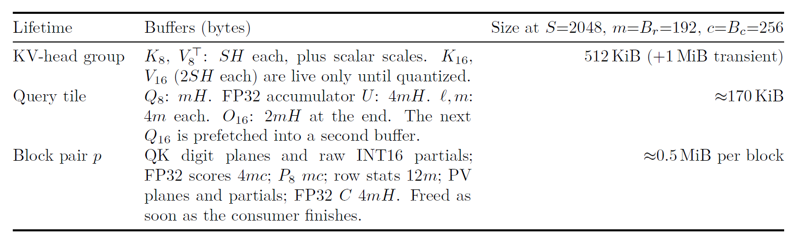

In [19]:
S, H, G = 2048, 128, 4                  # one KV-head group, one decode step
KiB, SRAM = 1024, 16 * 1024**2

cache = 2 * S * H                       # INT8 K + pre-transposed V: the whole context
acc = 4 * H * G + G * H                 # FP32 accumulator U, plus Q8
r = flash_decode(S=S, H=H, G=G, Bc = 1024, verbose=False, gantt_path=None)   # Bc=2048: one block, no streaming
peak = r["peak_sram_bytes"]

print("KV cache        ", cache / KiB, "KiB")
print("U + Q8          ", acc / KiB, "KiB")
print("packed operands ", (peak - cache - acc) / KiB, "KiB   # array-layout copy of K")
print("peak            ", peak / KiB, "KiB =", round(100 * peak / SRAM, 2), "% of 16 MiB")

plot("img/sram_bound.png", 800)

### Final Code

The implementation fixes three pipeline offsets:

1. the arrays queue QK(p+2) before PV (p) (QK_LEAD = 2);
2. the VCPU packs QK operands three blocks ahead (PACK_LOOKAHEAD = 3);
3. The in-order VCPU queue therefore never stalls waiting for PV (p).

    DMA load K16, V16: DRAM → SRAM
    VCPU quantize K16, V16 → K8, V8T; write scales to SRAM
    SRAM release K16, V16 after conversion

    FOR each grouped Q head
        FOR each query tile Qi
            DMA load Qi16: DRAM → SRAM
            VCPU quantize Qi16 → Qi8
            VCPU initialize U = 0, l = 0, m = -infinity
            SRAM release Qi16

            VCPU pack QK operands for blocks 0, 1, 2, if present
            SA1 & SA2 queue QK(0), QK(1), if present

            FOR p = 0 ... last key block
                SA1 & SA2 queue QK(p + 2), if present

                VCPU read QK(p) raw results from SRAM
                VCPU reconstruct and scale scores S
                VCPU apply causal mask

                VCPU compute:
                    m_new = maximum(m, rowmax(S))
                    alpha[p] = exp(m - m_new)
                    P = exp(S - m_new)
                    l = alpha[p] * l + rowsum(P)
                    m = m_new

                VCPU write updated m, l and alpha[p] to SRAM
                VCPU quantize P → P8
                VCPU pack P8, V8T for PV(p)

                VCPU pack QK(p + 3) operands, if present
                SA1 & SA2 queue PV(p); write raw results to SRAM

                IF p >= 1
                    VCPU reconstruct and scale PV(p - 1) → C
                    VCPU read U, C, alpha[p - 1]
                    VCPU write U = alpha[p - 1] * U + C
                    SRAM release consumed block buffers
                END IF
            END FOR

            VCPU reconstruct and scale the final PV → C
            VCPU write U = alpha[last] * U + C

            VCPU normalize O = U / l
            VCPU encode O16 and write to SRAM
            DMA store O16: SRAM → DRAM
            CPU wait for store completion
            SRAM release query-tile buffers
        END FOR
    END FOR

    SRAM release K8, V8T and scales

### Quantization

Better to notice that two Quantization method is worth to be applied

1. W8A16 outlier

Original LlaMA 8B is a BF16 model, while running on this architecture have to be W8A16. A quantization should be explicitly
designed for rounding.

Ref:  SageAttention2: Efficient Attention with Thorough Outlier Smoothing and Per-thread INT4 Quantization

2. Overflow Int8 -> Int16

For activation, Int 16 and Int8 are used and **radix-16 digit decomposition** has been applied for numerical accumulator stability

$A = A_0 + 16A_1, B = B_0 + 16B_1$

$AB = A_0 B_0 + 16A_0 B_1 + 16 A_1 B_0 + 256 A_1 B_1$

However, by applying such method will add roughly 4x latency due to the compution before

ref: BISMO: A Scalable Bit-Serial Matrix Multiplication Overlay for Reconfigurable Computing

# II. Task 2

`Identify and explain the bottleneck of this accelerator’s architecture for the flash-attention kernel,
i.e. the parameter with the largest elasticity with respect to time required for this kernel to complete`

In notebook 2 hardware profile we find the control latency in fact has a substantial impact on the efficiency of flash attention. The figure below plots the latency when all instructions are executed in a pipelined manner versus serialized, showing that the gap is considerable. control latency also affects its compute efficiency during SA computation.

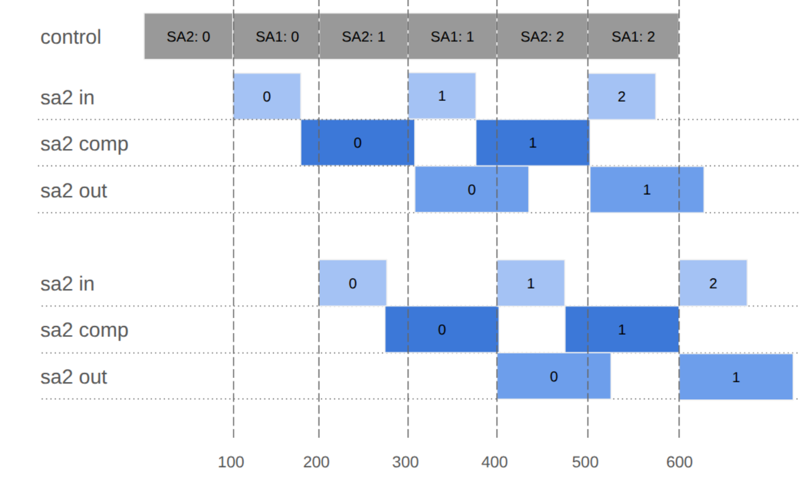

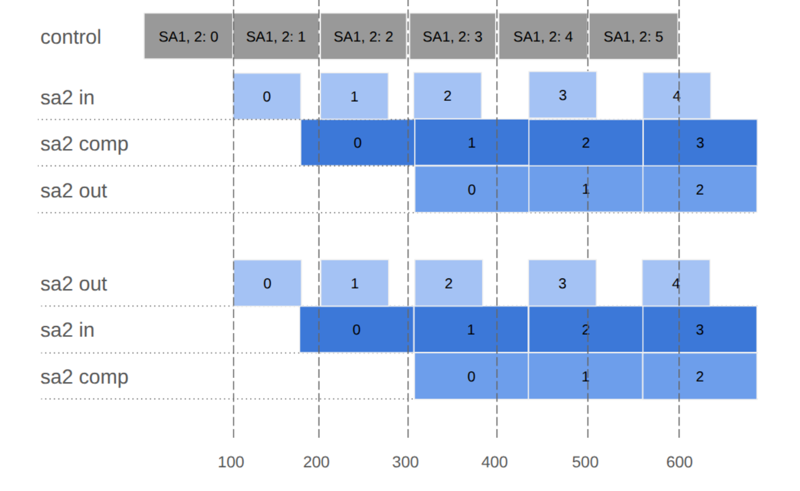

In [24]:
# Serialized control

plot("img/control_seq.png", 800)
# pipelined control

plot("img/control_pipeline.png", 800)

This result is directly reflected in the runtime of flash attention: simply changing how instructions arrive cuts the latency of FA by half.

In [23]:
hw_pip = Hardware(control="pipelined")
result_pipelined = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False, hw=hw_pip)

hw_seq = Hardware(control="serialized")
result_sequential = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False, hw=hw_seq)

print(f"pipelined cycles: {result_pipelined["cycles"]}", f"sequential cycles: {result_sequential["cycles"]}")
print(f"pipelined ms: {round(result_pipelined["time_ms"], 3)}", f"sequential ms: {round(result_sequential["time_ms"], 3)}")

pipelined cycles: 3119402 sequential cycles: 5434829
pipelined ms: 3.119 sequential ms: 5.435


Setting aside the command-latency factor, the choice of Bc has a major impact on FA efficiency during prefill, since tiling along Bc introduces additional overhead. In decode, on the other hand, R becomes the most influential setting.

In [30]:
hw = Hardware(control="pipelined")   # control latency removed

# Prefill: change ONE of Br, Bc, R from the baseline (192, 256, 256)
for Br, Bc, R in [(192, 256, 256),
                  (96, 256, 256), (384, 256, 256),
                  (192, 128, 256), (192, 512, 256),
                  (192, 256, 128), (192, 256, 64)]:
    t = flash_attention(T=T, S=S, H=H, G=G, Br=Br, Bc=Bc, R=R, hw=hw, verbose=False)["time_ms"]
    print(f"prefill Br={Br:3d} Bc={Bc:3d} R={R:3d}  {t:.3f} ms")

# Decode: only one query token, so no Br; change Bc or R from (1024, 256)
for Bc, R in [(1024, 256), (512, 256), (2048, 256), (1024, 128), (1024, 64)]:
    t = flash_decode(S=S, H=H, G=G, Bc=Bc, R=R, hw=hw, verbose=False)["time_ms"]
    print(f"decode  Bc={Bc:4d} R={R:3d}  {t*1000:.1f} us")

prefill Br=192 Bc=256 R=256  3.118 ms
prefill Br= 96 Bc=256 R=256  3.451 ms
prefill Br=384 Bc=256 R=256  3.138 ms
prefill Br=192 Bc=128 R=256  3.909 ms
prefill Br=192 Bc=512 R=256  3.092 ms
prefill Br=192 Bc=256 R=128  3.119 ms
prefill Br=192 Bc=256 R= 64  4.454 ms
decode  Bc=1024 R=256  29.1 us
decode  Bc= 512 R=256  31.7 us
decode  Bc=2048 R=256  29.4 us
decode  Bc=1024 R=128  29.3 us
decode  Bc=1024 R= 64  34.5 us


# III. Task 3

`Provide estimations of the TTFT (time to first token) and the interactivity (token generation rate) for
this workload and architecture. These numbers must be justified by a performance model which
takes into account the architectural constants detailed above`

By combining the efficiency model with the setting parameters obtained earlier, we can compute TTFT and TPOT in a simple and intuitive way.

Per layer, one 2048-token sequence (ridge 17.2 op/byte)
  FA          34.4 Gop      40.0 MiB    819.6 op/byte    882 op/cycle     39.0 ms
  MLP        721.6 Gop    1896.0 MiB    362.9 op/byte   1092 op/cycle    660.9 ms
  FA+MLP     755.9 Gop    1936.0 MiB    372.4 op/byte   1080 op/cycle    699.9 ms
TTFT:  22.4 s


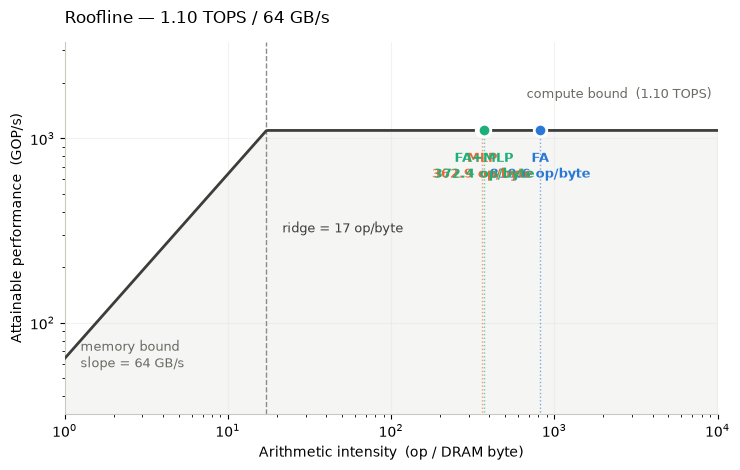

In [31]:
from helper import plot_roofline
from mlp import mlp
from fa import flash_attention
from tile_model import Hardware, data_bytes, divup

hw = Hardware()
Mt = 192
fa = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, Br_sa1=None, R=256, hw=hw, verbose=False)
ml = mlp(M=T, D=D, F=F, Mt=Mt, Ft=256, Mt_sa1=None, R=256, hw=hw, verbose=False)

# FA, K for K groups per layer
fa_ops   = K * 2 * 2 * G * H * T * (T + 1) // 2           # QK^T + PV
fa_bytes = K * (data_bytes((2*S, H), 16) + data_bytes((2*G*T, H), 16))
fa_cyc   = K * fa['cycles']

# MLP:
mlp_ops   = 2 * T * 3 * D * F                              # gate, up, down
mlp_bytes = data_bytes((3*T, D), 16) + divup(T, Mt) * data_bytes((3*D, F), 8)
mlp_cyc   = ml['cycles']

ridge_ops, ridge_mem = 2 * 552, hw.dma_bw                    # op/cycle, byte/cycle
rows = [("FA", fa_ops, fa_bytes, fa_cyc), ("MLP", mlp_ops, mlp_bytes, mlp_cyc),
        ("FA+MLP", fa_ops + mlp_ops, fa_bytes + mlp_bytes, fa_cyc + mlp_cyc)]

print(f"Per layer, one {T}-token sequence (ridge {ridge_ops/ridge_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    print(f"  {name:7s} {ops/1e9:8.1f} Gop  {nbytes/2**20:8.1f} MiB  "
          f"{ops/nbytes:7.1f} op/byte  {ops/cyc:5.0f} op/cycle  {hw.time_us(cyc)/1e3:7.1f} ms")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows], ridge_ops, ridge_mem)

print("TTFT: ", round(L * hw.time_us(cyc)/1e3/1e3, 1), "s")

Per layer, one decode step of B=16 sequences at S=2048 context (ridge 17.2 op/byte)
  FA        0.537 Gop    64.2 MiB    8.0 op/byte    118 op/cycle   4.564 ms     23% of the memory roof
  MLP       5.637 Gop   168.4 MiB   31.9 op/byte   1029 op/cycle   5.479 ms     93% of the compute roof
  FA+MLP    6.174 Gop   232.6 MiB   25.3 op/byte    615 op/cycle  10.043 ms     56% of the compute roof
TPOT: 321.4 ms/step = 20.09 ms/token, 50 tok/s aggregate
  floors per step: weights 88.1 ms, KV cache 33.6 ms


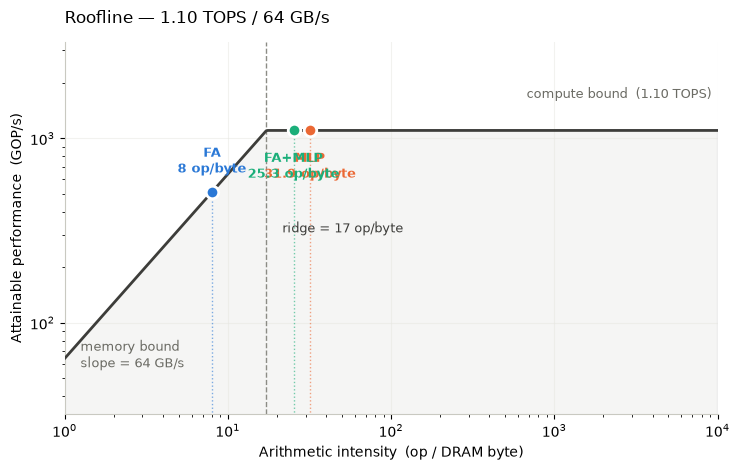

In [32]:
from fa import flash_decode
from mlp import mlp_decode
from helper import B


fad = flash_decode(S=S, H=H, G=G, Bc=1024, R=256, hw=hw, verbose=False)
mld = mlp_decode(M=B, D=D, F=F, Ft=256, R=256, hw=hw, verbose=False)

fad_ops   = B * K * 2 * 2 * G * H * S                    # QK^T + PV
fad_bytes = B * K * (data_bytes((2*S, H), 8)             # INT8 K + pre-transposed V
                     + data_bytes((2*G, H), 16))         # Q16 in, O16 out
fad_cyc   = B * K * fad['cycles']

mld_ops   = 2 * B * 3 * D * F                            # gate, up, down
mld_bytes = data_bytes((3*B, D), 16) + data_bytes((3*D, F), 8)   # weights once per step
mld_cyc   = mld['cycles']

rows = [("FA", fad_ops, fad_bytes, fad_cyc), ("MLP", mld_ops, mld_bytes, mld_cyc),
        ("FA+MLP", fad_ops + mld_ops, fad_bytes + mld_bytes, fad_cyc + mld_cyc)]

print(f"Per layer, one decode step of B={B} sequences at S={S} context "
      f"(ridge {ridge_ops/ridge_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    roof = min(ridge_ops, ops/nbytes * ridge_mem)        # the roofline at this intensity
    print(f"  {name:7s} {ops/1e9:7.3f} Gop {nbytes/2**20:7.1f} MiB {ops/nbytes:6.1f} op/byte"
          f" {ops/cyc:6.0f} op/cycle {hw.time_us(cyc)/1e3:7.3f} ms"
          f"   {100*ops/cyc/roof:4.0f}% of the {'compute' if roof == ridge_ops else 'memory'} roof")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows],
              ridge_ops, ridge_mem)

step = L * (fad_cyc + mld_cyc)
print(f"TPOT: {hw.time_us(step)/1e3:.1f} ms/step = {hw.time_us(step)/1e3/B:.2f} ms/token, "
      f"{B/(hw.time_us(step)/1e6):.0f} tok/s aggregate")
print(f"  floors per step: weights {L*3*D*F/hw.dma_bw/1e6:.1f} ms, "
      f"KV cache {L*B*K*2*S*H/hw.dma_bw/1e6:.1f} ms")

# IV. Task 4

`Suggest 2 architectural improvements to the accelerator that would improve the interactivity`

When running FA2 on the accelerator, the biggest bottleneck is **command latency**: switching to pipelined instructions cuts the runtime by more than 30%. _(output port x2 + pipelined + bandwidth, pipelined + bandwidth model)_

_output port x2 + pipelined + bandwidth           2.858 ms  arrays  54.6%  vcpu  99.7%  dma  4.0%_   suggests that if the SA unit follows the **bandwidth model**, the array is no longer the bottleneck; instead, the **VCPU's bandwidth becomes the new one**.

This result can also be valided by the control bound analysis as following:


In [20]:
import tile_model
import fa
import sys, dataclasses

def run(label, hw, **kw):
    fa._array_matmul.cache_clear(); fa._balanced_split.cache_clear()
    r = fa.flash_attention(T=2048, S=2048, H=128, G=4, Br=192, Bc=256, Br_sa1=None, R=256, hw=hw, verbose=False, **kw)
    u = r['utilization']
    macs = 4*sum(m*c*128*2 for _ in [0] for m,c in [(192,256)])  # placeholder
    print(f'{label:46s} {r["time_ms"]:7.3f} ms  arrays {100*u["SA1+SA2"]:5.1f}%  vcpu {100*u["VCPU"]:5.1f}%  dma {100*u["DMA"]:4.1f}%')

    return r

base = tile_model.Hardware()

run('baseline', base)
run('DMA bandwidth x4', dataclasses.replace(base, dma_bw=256))
run('vector bandwidth x2', dataclasses.replace(base, vector_bw=256))
run('vector launch 300 -> 0', dataclasses.replace(base, vector_launch=0))
run('array command latency 100 -> 0', dataclasses.replace(base, array_latency=0))
run('pipelined command issue', dataclasses.replace(base, control='pipelined'))
run('array_model=bandwidth (no MAC limit)', dataclasses.replace(base, array_model='bandwidth'))
run('pipelined + bandwidth model', dataclasses.replace(base, control='pipelined', array_model='bandwidth'))
# output port 8 -> 16 B/cycle (class attribute, patched for the experiment only)
tile_model.SystolicArray.BW_out = 16
run('output port 8 -> 16 B/cycle (mac model)', base)
run('output port x2 + pipelined', dataclasses.replace(base, control='pipelined'))
run('output port x2 + pipelined + bandwidth', dataclasses.replace(base, control='pipelined', array_model='bandwidth'))
tile_model.SystolicArray.BW_out = 8
run('pipelined + vector bw x2', dataclasses.replace(base, control='pipelined', vector_bw=256))
print()

baseline                                         4.873 ms  arrays  99.4%  vcpu  58.4%  dma  2.4%
DMA bandwidth x4                                 4.867 ms  arrays  99.6%  vcpu  58.5%  dma  1.1%
vector bandwidth x2                              4.869 ms  arrays  99.5%  vcpu  33.4%  dma  2.4%
vector launch 300 -> 0                           4.871 ms  arrays  99.5%  vcpu  50.1%  dma  2.4%
array command latency 100 -> 0                   3.078 ms  arrays  98.7%  vcpu  92.5%  dma  3.8%
pipelined command issue                          3.118 ms  arrays  98.8%  vcpu  91.3%  dma  3.7%
array_model=bandwidth (no MAC limit)             3.761 ms  arrays  99.2%  vcpu  75.6%  dma  3.1%
pipelined + bandwidth model                      2.856 ms  arrays  68.2%  vcpu  99.7%  dma  4.1%
output port 8 -> 16 B/cycle (mac model)          4.847 ms  arrays  99.4%  vcpu  58.8%  dma  2.4%
output port x2 + pipelined                       3.094 ms  arrays  98.7%  vcpu  92.1%  dma  3.7%
output port x2 + pipelined + b

# V. Task 5

 Suppose that 4 such accelerators can be connected to a single host CPU.
1. • How would you parallelize the computation of this workload across the 4 accelerators?
2. • What is the theoretical maximum interactivity that can be achieved by this system?
3. • What is the minimum required data bandwidth between the host CPU and the 4 accelerators to
4. achieve 70% of the theoretical maximum interactivity?


In practice, tensor parallelism is the most straightforward and easiest form of parallelism to implement in this system. It partitions the weight matrix column-wise in an almost self-evident way, allowing the GEMMs to be computed in parallel across multiple accelerators, with the only extra cost being a single all-reduce. In FA, each group of four heads shares the same KV, so no additional splitting of the KV is required. Pipeline parallelism was also run alongside tensor parallelism as a baseline for comparison, but because of the overhead introduced by the extra tiny batches, it in fact takes considerably more time than tensor parallelism alone. Parameter sharding was not considered because the weights of Llama 3.1 8B fit in a single DRAM; distributing them across several DRAMs does not meet the design requirements and would also increase the interactivity overhead.

In [34]:
from parallel import tensor_parallel_prefill, tensor_parallel_decode

## Prefill

h = Hardware()
base_prefill = tensor_parallel_prefill(1, Mt, h)['cycles']   # one accelerator, same hardware
base_decode = tensor_parallel_decode(1, h)['cycles']   # one accelerator, same hardware
n = 4

print("*" * 12, "Prefill", "*" * 12)
print(f"Per layer, one {T}-token sequence")
tpr = tensor_parallel_prefill(n, Mt, h)
ms = lambda c: h.time_us(c) / 1e3
print(f"n={n} \n"
      f"attention {ms(tpr['att']):6.1f} ms \n"
      f"MLP {ms(tpr['mlp']):6.1f} ms  \n"
      f"all-reduce {ms(tpr['allreduce']):6.1f} ms \n"
      f"layer {ms(tpr['cycles']):6.1f}ms "
      f"speedup: x{base_prefill / tpr['cycles']:4.2f} \n"
      f"TTFT {L * ms(tpr['cycles']) / 1e3:4.1f} s \n"
      f"bottleneck: attention <- {tpr['bound'][0]}\n"
      f"MLP <- {tpr['bound'][1]}")


print("*" * 12, "Decode", "*" * 12)
print(f"Per layer, one decode step of B={B} sequences at S={S} context")
tpd = tensor_parallel_decode(n, h)
ms = lambda c: h.time_us(c) / 1e3
print(f"n={n} \n"
      f"attention {ms(tpd['att']):6.2f} ms \n"
      f"MLP {ms(tpd['mlp']):6.2f} ms  \n"
      f"all-reduce {ms(tpd['allreduce']):6.3f} ms \n"
      f"layer {ms(tpd['cycles']):6.2f}ms "
      f"speedup: x{base_decode / tpd['cycles']:4.2f} \n"
      f"TPOT {L * ms(tpd['cycles']) / B:5.2f} ms/token, {B / (L * ms(tpd['cycles']) / 1e3):.0f} tok/s \n"
      f"bottleneck: attention <- {tpd['bound'][0]}\n"
      f"MLP <- {tpd['bound'][1]}")


************ Prefill ************
Per layer, one 2048-token sequence
n=4 
attention   27.8 ms 
MLP  369.9 ms  
all-reduce    0.2 ms 
layer  397.8ms speedup: x1.76 
TTFT 12.7 s 
bottleneck: attention <- host command interface
MLP <- host command interface
************ Decode ************
Per layer, one decode step of B=16 sequences at S=2048 context
n=4 
attention   1.72 ms 
MLP   2.93 ms  
all-reduce  0.014 ms 
layer   4.66ms speedup: x2.16 
TPOT  9.32 ms/token, 107 tok/s 
bottleneck: attention <- host command interface
MLP <- host command interface


In [35]:
from parallel import pipeline_tensor_parallel_prefill
from helper import B, T, L

nt, np_ = 2, 2     # nt accelerators per tensor-parallel group, np_ groups as pipeline stages

print("*" * 12, "Pipeline x tensor parallel prefill", "*" * 12)
print(f"All {L} layers, B={B} sequences of {T} tokens, "
      f"nt={nt} x np={np_} = {nt * np_} accelerators")
ms = lambda c: h.time_us(c) / 1e3

for one_host in (True, False):
    ptp = pipeline_tensor_parallel_prefill(nt, np_, Mt, m=B, hw=h, one_host=one_host)
    layer = ptp['layer']
    print(f"--- {'one shared host' if one_host else 'one host per stage'} \n"
          f"layers per stage {ptp['stages']} \n"
          f"layer {ms(layer['cycles']):6.1f} ms "
          f"(attention {ms(layer['att']):.1f}, MLP {ms(layer['mlp']):.1f}, all-reduce {ms(layer['allreduce']):.1f}) \n"
          f"stage hand-off {ms(ptp['send']):6.2f} ms \n"
          f"TTFT {ms(ptp['ttft']) / 1e3:5.1f} s \n"
          f"batch {ms(ptp['cycles']) / 1e3:6.1f} s, {B * T / (ms(ptp['cycles']) / 1e3):.0f} tok/s \n"
          f"bubble {ptp['bubble']:.1%} \n"
          f"speedup: x{ptp['speedup']:4.2f} \n"
          f"bottleneck: attention <- {ptp['bound'][0]}\n"
          f"MLP <- {ptp['bound'][1]}")

************ Pipeline x tensor parallel prefill ************
All 32 layers, B=16 sequences of 2048 tokens, nt=2 x np=2 = 4 accelerators
--- one shared host 
layers per stage [16, 16] 
layer  795.4 ms (attention 55.6, MLP 739.7, all-reduce 0.0) 
stage hand-off   0.01 ms 
TTFT  25.5 s 
batch  216.3 s, 151 tok/s 
bubble 5.9% 
speedup: x1.66 
bottleneck: attention <- host command interface
MLP <- host command interface
--- one host per stage 
layers per stage [16, 16] 
layer  397.7 ms (attention 27.8, MLP 369.9, all-reduce 0.0) 
stage hand-off   0.01 ms 
TTFT  12.7 s 
batch  108.2 s, 303 tok/s 
bubble 5.9% 
speedup: x3.31 
bottleneck: attention <- host command interface
MLP <- host command interface


We observe that tensor parallelism yields a TTFT roughly 2× faster than the non-parallel case, i.e. close to a 2× speedup. In contrast, grouping two accelerators for tensor parallelism and then running pipeline parallelism across two such groups actually increases TTFT. Finally, varying the bandwidth has only a limited effect on tensor parallelism, since the only overhead is a single all-reduce after the BTD computation; simulations in the performance model confirm that this effect is negligible.